# 02 Arc-Length Resampling and the Next Step

This notebook walks through the next minimal stage of the particle-prediction pipeline:

1. load latent trajectories
2. smooth them in time
3. compute cumulative latent-space arc length
4. resample each smoothed trajectory at a fixed arc-length increment `delta_s`

The transition bank is intentionally not implemented here yet. This notebook stops at resampled trajectories and uses simple plots to check that the geometry looks sensible.

## What To Inspect

The main checks in this notebook are:

- cumulative arc length should start at zero and increase monotonically
- the resampling grid should use a shared explicit `delta_s`
- resampled points should stay on the smoothed latent trajectory
- source lineage should remain available through the resampled object

If those checks look good, the next step is transition-window extraction.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "dev" / "particle_prediction" / "data" / "loading.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dev.particle_prediction.data.loading import load_trajectories
from dev.particle_prediction.data.resampling import compute_cumulative_arc_length, resample_smoothed_trajectories
from dev.particle_prediction.data.smoothing import smooth_trajectories
from dev.particle_prediction.data.transition_windows import build_transition_windows_for_dataset

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)

print(f"Project root: {project_root}")

Project root: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq


## Load, Smooth, and Resample

This example is preconfigured for the `20251207_pbx` experiment. We use a shared smoothing scale in seconds and a shared resampling step size in latent-space arc length.

In [2]:
build_dir = Path("/net/trapnell/vol1/home/mdcolon/proj/morphseq/morphseq_playground/metadata/build06_output")
experiment_ids = ["20251207_pbx"]
window_seconds = 10.0 * 60.0
poly_order = 2
delta_s = 0.25

dataset = load_trajectories(
    build_dir=build_dir,
    experiment_ids=experiment_ids,
    n_components=10,
    min_trajectory_length=3,
    verbose=False,
 )
smoothed = smooth_trajectories(
    dataset.trajectories[:5],
    window_seconds=window_seconds,
    poly_order=poly_order,
 )
resampled = resample_smoothed_trajectories(
    smoothed,
    delta_s=delta_s,
 )

summary_df = pd.DataFrame(
    {
        "embryo_id": [traj.source.embryo_id for traj in resampled],
        "n_raw": [len(traj.source.time_seconds) for traj in resampled],
        "n_resampled": [len(traj.arc_length) for traj in resampled],
        "delta_t": [traj.source.delta_t for traj in resampled],
        "total_arc_length": [traj.arc_length[-1] for traj in resampled],
        "delta_s": [traj.delta_s for traj in resampled],
    }
)

print(f"Loaded {len(dataset)} raw trajectories from {experiment_ids}")
summary_df

Loaded 94 raw trajectories from ['20251207_pbx']


,embryo_id,n_raw,n_resampled,delta_t,total_arc_length,delta_s
0,20251207_pbx_A01_e01,52,712,1951.9078,177.6450,0.25
1,20251207_pbx_A02_e01,89,1309,1951.9078,326.8016,0.25
2,20251207_pbx_A03_e01,96,1636,1951.9078,408.7229,0.25
3,20251207_pbx_A04_e01,78,952,1951.9078,237.5365,0.25
4,20251207_pbx_A05_e01,82,1422,1951.9078,355.0180,0.25


## Inspect Arc-Length Parameterization

Here we examine one example trajectory in detail. The first table compares original time, cumulative arc length, and interpolated resampled time. The plot should show a monotone arc-length curve and evenly spaced resampling locations along it.

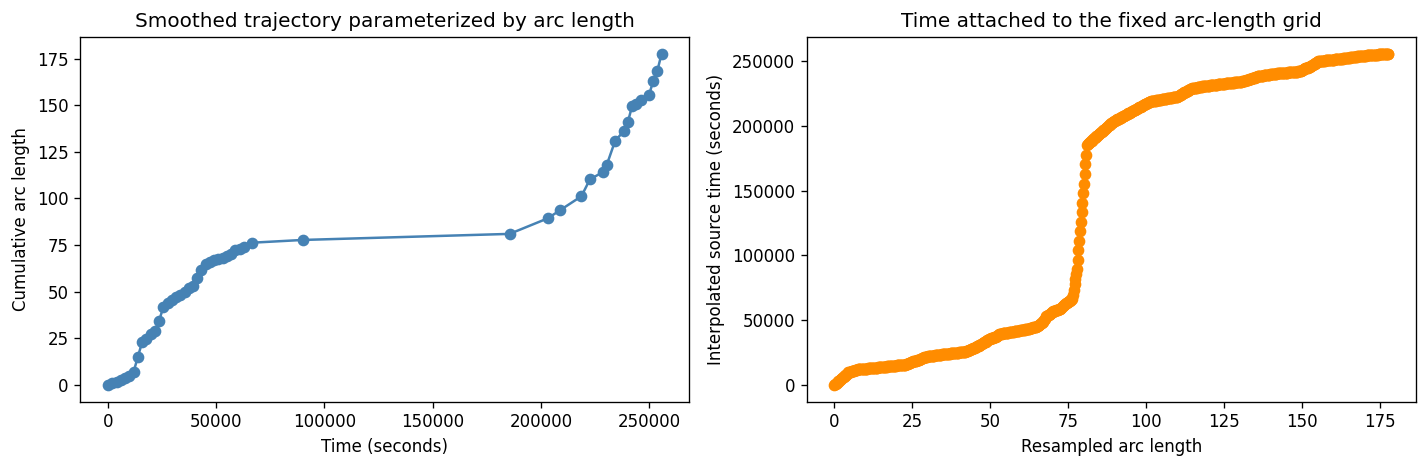

Source arc-length table


,source_time_seconds,source_arc_length
0,0.0000,0.0000
1,2153.2437,0.9228
2,4113.5540,1.8556
3,6076.1586,2.7372
4,8042.6496,3.7467



Resampled grid table


,resampled_arc_length,interp_time_seconds
0,0.00,0.0000
1,0.25,583.3267
2,0.50,1166.6534
3,0.75,1749.9801
4,1.00,2315.4272


In [3]:
example_smoothed = smoothed[0]
example_resampled = resampled[0]
source_arc_length = compute_cumulative_arc_length(example_smoothed.smoothed)

arc_length_df = pd.DataFrame(
    {
        "source_time_seconds": example_smoothed.time_seconds,
        "source_arc_length": source_arc_length,
    }
)
resampled_df = pd.DataFrame(
    {
        "resampled_arc_length": example_resampled.arc_length,
        "interp_time_seconds": example_resampled.source_time_interp,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(example_smoothed.time_seconds, source_arc_length, marker="o", color="steelblue")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Cumulative arc length")
axes[0].set_title("Smoothed trajectory parameterized by arc length")

axes[1].plot(example_resampled.arc_length, example_resampled.source_time_interp, marker="o", color="darkorange")
axes[1].set_xlabel("Resampled arc length")
axes[1].set_ylabel("Interpolated source time (seconds)")
axes[1].set_title("Time attached to the fixed arc-length grid")

plt.tight_layout()
plt.show()

print("Source arc-length table")
display(arc_length_df.head())
print()
print("Resampled grid table")
display(resampled_df.head())

## Extract and Inspect Transition Windows

This final section performs the first canonical modeling step after resampling: transition-window extraction.

Each window contains:

- the current resampled state
- the next-step increment
- the ordered recent history segments ending at that state
- lineage fields such as embryo, experiment, class, and resampled index

This is the last step in the notebook. Building a searchable transition bank can come later on top of these windows.

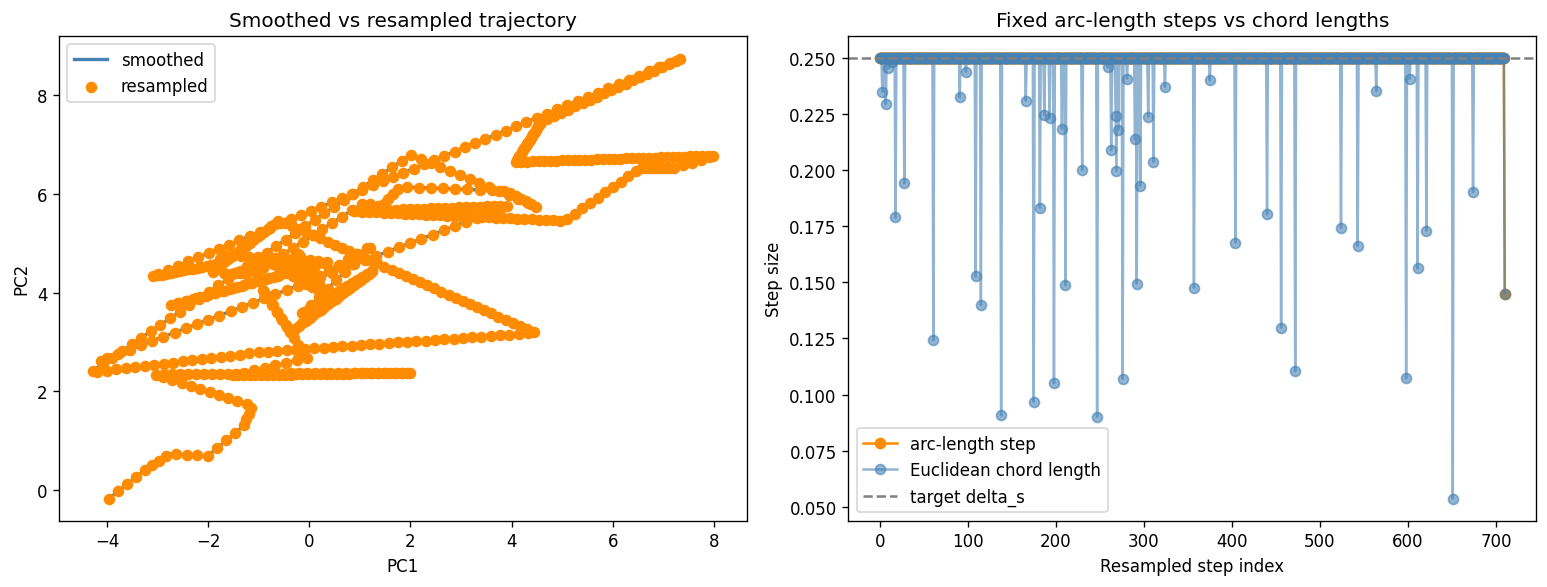

Next step: build transition windows from these resampled trajectories.


In [ ]:
history_length = 3
windows = build_transition_windows_for_dataset(resampled, history_length=history_length)

window_summary = pd.DataFrame(
    {
        "embryo_id": [traj.source.embryo_id for traj in resampled],
        "n_resampled_points": [len(traj.arc_length) for traj in resampled],
        "n_windows": [max(len(traj.arc_length) - history_length - 1, 0) for traj in resampled],
    }
)

example_window = windows[0]
example_trajectory = next(traj for traj in resampled if traj.source.embryo_id == example_window.embryo_id)
history_points = example_trajectory.resampled[
    example_window.resampled_index - history_length : example_window.resampled_index + 1
]
next_point = example_window.state + example_window.increment

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    example_trajectory.resampled[:, 0],
    example_trajectory.resampled[:, 1],
    color="lightgray",
    lw=2,
    label="resampled trajectory",
)
axes[0].plot(
    history_points[:, 0],
    history_points[:, 1],
    color="steelblue",
    lw=3,
    marker="o",
    label="history path",
)
axes[0].scatter(
    example_window.state[0],
    example_window.state[1],
    color="darkorange",
    s=80,
    label="current state",
    zorder=6,
)
axes[0].scatter(
    next_point[0],
    next_point[1],
    color="red",
    s=80,
    marker="*",
    label="next state",
    zorder=7,
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Example transition window in latent space")
axes[0].legend()

axes[1].axis("off")
axes[1].set_title("Example window contents")
window_text = "\n".join([
    f"embryo_id: {example_window.embryo_id}",
    f"experiment_id: {example_window.experiment_id}",
    f"class: {example_window.perturbation_class}",
    f"resampled_index: {example_window.resampled_index}",
    f"arc_length_value: {example_window.arc_length_value:.3f}",
    f"source_time_estimate: {example_window.source_time_estimate:.3f}",
    f"state: {np.array2string(example_window.state, precision=3)}",
    f"increment: {np.array2string(example_window.increment, precision=3)}",
    f"history_segments shape: {example_window.history_segments.shape}",
])
axes[1].text(0.0, 1.0, window_text, va="top", ha="left", family="monospace")

plt.tight_layout()
plt.show()

print(f"Built {len(windows)} transition windows with history_length={history_length}")
display(window_summary)
print()
print("Example history segments")
display(pd.DataFrame(example_window.history_segments))